
# **NPV фиксированной и плавающей сторон одно-периодного свопа**

---

Рассматривается одно-периодный своп на промежутке времени
$
[T_0,T_n],
$
по которому в момент $T_n$ производится единственная неттинговая выплата.

Своп имеет две стороны:

* **фиксированная сторона** платит или получает заранее оговоренную ставку (K),
* **плавающая сторона** платит арифметическое среднее ежедневных overnight-ставок на интервале.

Требуется, используя:

* предоставленную **кривую дисконт-факторов** $P(0,t)$;
* параметры модели **Hull–White** под терминальной мерой;
* параметры свопа;

вычислить справедливую величину:

$
\boxed{\text{NPV} = PV_{\text{fix}} - PV_{\text{float}}}
$

### **Параметры свопа**

| Параметр             | Значение                 |
| -------------------- | ------------------------ |
| Номинал              | 1 000 000 000            |
| Дата начала          | 10/06/2025               |
| Дата окончания       | 10/06/2026               |
| Календарь            | MOS                      |
| Day count            | ACT/365                  |
| Фиксированная ставка | 14.5%                    |
| Позиция по фикс      | Receive                  |
| Плавающая ставка     | Arithmetic average ON    |
| Позиция по плавающ.  | Pay                      |

---

### **Параметры модели Hull–White**

| Параметр                    | Значение   |
| --------------------------- | ---------- |
| Скорость mean-reversion (a) | 0.75       |
| Волатильность (\sigma)      | 0.25       |
| Дата оценки                 | 10/06/2025 |

---

### **Кривая дисконт-факторов**

| Дата     | DF     |
| -------- | ------ |
| 10/15/25 | 0.9958 |
| 10/22/25 | 0.9927 |
| 11/10/25 | 0.9840 |
| 12/9/25  | 0.9710 |
| 1/13/26  | 0.9559 |
| 4/8/26   | 0.9213 |
| 7/8/26   | 0.8897 |
| 10/8/26  | 0.8626 |



### **Фиксированная выплата**

С фиксированной стороны выплачивается:

$
\text{Fix} = N K \tau ,
$

где
$
\tau = T_n - T_0 \quad (\text{ACT/365}).
$

Текущая стоимость:

$
PV_{\text{fix}} = N \cdot K \cdot \tau \cdot P(0, T_n).
$

---

###  **Плавающая выплата**

<!-- Плавающая сторона платит:

<!-- $
\bar r = \frac{1}{m}\sum_{i=0}^{m-1}  r_{t_i},
$ -->

<!-- где $r_{t_i}$ — overnight-ставка, применимая к дате $t_i$. --> 

Текущая стоимость:

$
PV_{\text{float}} = N \cdot \mathbb{E}^{T_n}\left[\bar r\right]\cdot P(0,T_n) \cdot\tau,
$ 


$
    \mathbb{E}^{T_n}[\bar{r}] = \frac{1}{T_n - T_0} \sum_{i=0}^{m-1} \tau_i \mathbb{E}^{T_n}[r_{t_i}],
    \quad  \tau_i = t_{i+1} - t_i.
$


---

####  **Итоговая цель**

$
\boxed{
\text{NPV} = PV_{\text{fix}} - PV_{\text{float}}
}
$

---




<!-- ===================== -->



<!-- Hull-White Model:
$$dr_t = \kappa (\theta(t)-r_t)dt + \sigma(t)dW_t^Q$$

Из-за сложности моделирования перейдём в форвардную меру.    


Возьмём вспомогательный процесс 

$\tilde{r_t} = -\kappa r_t dt + \sigma(t) dW_t^Q$ (Vasicec с $\theta(t)=0$),   
$\tilde{r_0} = f^*(0,0)$

$\mathbb{E}^{Q}_t [e^{\int_t^T\tilde{r_t}ds}] = e^{A(t,T) - B(t,T)\tilde{r_t}}$,

$B(t,T) = \frac{1 - e^{-\kappa(T-t)}}{\kappa}$, 
$A(t,T) = \frac12 \int_t^T B^2(s,T)\sigma^2(s) ds$

Найдём $\theta(t)$ таким образом, чтобы наша модель попадала в кривую: -->


<!-- 

Аналогично лекции 7, перепишем в новом представлении: $r_t = x_t + \alpha(t)$, где 


$dx_t = -\kappa x_t dt + \sigma(t) dW_t^Q$,   $x_0 = 0$ -->




<!-- ================= -->



###  Hull-White:

Воспользуемся результатами лекций 6,7:

Модель Халла-Уайта является расширением модели Васичека с детерминированными зависящими от времени параметрами. Под риск-нейтральной мерой $\mathbb{Q}$ краткосрочная ставка $r_t$ удовлетворяет стохастическому дифференциальному уравнению:

$$
dr_t = \kappa (\theta(t) - r_t) dt + \sigma(t) dW_t^{\mathbb{Q}},
$$

<!-- где $\kappa > 0$ — постоянная скорость возврата к среднему, $\theta(t)$ — детерминированная функция, задающая уровень среднего возврата, $\sigma(t)$ — детерминированная функция волатильности, $W_t^{\mathbb{Q}}$ — винеровский процесс под мерой $\mathbb{Q}$. -->

Для калибровки модели к начальной форвардной кривой $f^*(0,t)$ введём вспомогательный процесс $x_t$ и функцию $\alpha(t)$ такие, что

$$
r_t = x_t + \alpha(t),
$$

где

$$
dx_t = -\kappa x_t dt + \sigma(t) dW_t^{\mathbb{Q}}, \quad x_0 = 0,
$$

а функция $\alpha(t)$ задается соотношением

$$
\alpha(t) = f^*(0,t) + \frac{1}{\kappa} \int_0^t \sigma^2(s) e^{-\kappa(t-s)} \left(1 - e^{-\kappa(t-s)}\right) ds.
$$


### Представление под форвардной мерой:

Для даты платежа $T$ удобно работать под $T$-форвардной мерой $\mathbb{Q}^T$, связанной с numeraire $P(t,T)$. Мера $\mathbb{Q}^T$ определяется через производную Радона-Никодима

$$
\left. \frac{d\mathbb{Q}^T}{d\mathbb{Q}} \right|_{\mathcal{F}_T} = \frac{P(T,T)}{B_T} \cdot \frac{B_0}{P(0,T)} = \frac{1}{P(0,T) B_T},
$$

где $B_t = e^{\int_0^t r_s ds}$ — банковский счет.

С помощью теоремы Гирсанова получаем, что процесс

$$
dW_t^T = dW_t^{\mathbb{Q}} + B(t,T) \sigma(t) dt
$$

является винеровским процессом под мерой $\mathbb{Q}^T$, где

$$
B(t,T) = \frac{1 - e^{-\kappa (T-t)}}{\kappa}.
$$

Динамика процесса $x_t$ под мерой $\mathbb{Q}^T$ имеет вид

$$
dx_t = \left( -B(t,T) \sigma^2(t) - \kappa x_t \right] dt + \sigma(t) dW_t^T.
$$

Вводя процесс Орнштейна-Уленбека $x_t^T$ такой, что

$$
dx_t^T = -\kappa x_t^T dt + \sigma(t) dW_t^T, \quad x_0^T = 0,
$$

получим его явный вид:
Умножим обе части уравнения на $e^{\kappa t}$:

$$
e^{\kappa t} dx_t^T + \kappa e^{\kappa t} x_t^T dt = e^{\kappa t} \sigma(t) dW_t^T.
$$

$$
d\left(e^{\kappa t} x_t^T\right) = e^{\kappa t} dx_t^T + \kappa e^{\kappa t} x_t^T dt.
$$

$$
\int_0^t d\left(e^{\kappa s} x_s^T\right) = \int_0^t e^{\kappa s} \sigma(s) dW_s^T.
$$


$$
e^{\kappa t} x_t^T - e^{\kappa \cdot 0} x_0^T = \int_0^t e^{\kappa s} \sigma(s) dW_s^T.
$$

Учитывая начальное условие $x_0^T = 0$:

$$
e^{\kappa t} x_t^T = \int_0^t e^{\kappa s} \sigma(s) dW_s^T.
$$



Разрешая относительно $x_t^T$, находим явное выражение:

$$
\boxed{x_t^T = e^{-\kappa t} \int_0^t e^{\kappa s} \sigma(s) dW_s^T}.
$$



Рассмотрим $y_t = x_t - x_t^T$. Динамика:

$$
\begin{aligned}
dy_t &= dx_t - dx_t^T \\
&= \left[ -\kappa x_t - B(t,T)\sigma^2(t) \right] dt + \sigma(t) dW_t^T - \left[ -\kappa x_t^T dt + \sigma(t) dW_t^T \right] \\
&= -\kappa (x_t - x_t^T) dt - B(t,T)\sigma^2(t) dt \\
&= -\kappa y_t dt - B(t,T)\sigma^2(t) dt.
\end{aligned}
$$

умножив на $e^{\kappa t}$:

$$
e^{\kappa t} dy_t + \kappa e^{\kappa t} y_t dt = - e^{\kappa t} B(t,T)\sigma^2(t) dt.
$$
$$
e^{\kappa t} y_t - y_0 = -\int_0^t e^{\kappa s} B(s,T)\sigma^2(s) ds.
$$

Учитывая, что $y_0 = x_0 - x_0^T = 0$, получаем:

$$
y_t = -\int_0^t e^{-\kappa(t-s)} B(s,T)\sigma^2(s) ds.
$$

Таким образом,

$$
\boxed{x_t = x_t^T - \int_0^t e^{-\kappa(t-s)} B(s,T) \sigma^2(s) ds}.  \tag{*}
$$


<!-- 
Тогда краткосрочная ставка выражается как

$$
r_t = f^*(0,t) + x_t^T + \alpha_T(t),
$$

где

$$
\alpha_T(t) = -\int_0^t e^{-\kappa(t-s)} [B(s,t) - B(s,T)] \sigma^2(s) ds = -B(t,T) \operatorname{Var}[x_t^T].
$$

Для постоянной волатильности $\sigma$ дисперсия $\operatorname{Var}[x_t^T]$ вычисляется аналитически:

$$
\operatorname{Var}[x_t^T] = \sigma^2 \int_0^t e^{-2\kappa (t-s)} ds = \frac{\sigma^2}{2\kappa} \left(1 - e^{-2\kappa t}\right).
$$

### 3. Цена бескупонной облигации в модели Халла-Уайта

В модели Халла-Уайта цена бескупонной облигации может быть записана в виде

$$
P(t,T) = \frac{P(0,T)}{P(0,t)} \exp\left( -B(t,T) x_t^T + \frac{1}{2} B^2(t,T) \operatorname{Var}[x_t^T] \right).
$$ -->

<!-- Это представление удобно для расчетов под форвардной мерой. -->



По формуле (*), взяв форвардную меру $T_1$:
$$
x_t = x_t^{T_1} - \int_0^t e^{-\kappa(t-s)} B(s,T_1) \sigma^2(s) ds, 
$$

и, взяв другую форвардную меру $T_2$:
$$
x_t = x_t^{T_2} - \int_0^t e^{-\kappa(t-s)} B(s,T_2) \sigma^2(s) ds, 
$$

получим связь между ними: 
$$
x_t^{T1} - \int_0^t e^{-\kappa(t-s)} B(s,T_1) \sigma^2(s) ds = x_t^{T_2} - \int_0^t e^{-\kappa(t-s)} B(s,T_2) \sigma^2(s) ds
$$

$$
x_t^{T_1}  = x_t^{T_2} + \int_0^t e^{-\kappa(t-s)}(B(s,T_1)-B(s,T_2)) \sigma^2(s) ds
$$


Overnight ставка:

- $P(t_i, t_{i+1})$ — цена облигации в момент $t_i$ с погашением в $t_{i+1}$
- $\tau_i = t_{i+1} - t_i$ — длина периода (по соответствующей конвенции)


$$
P(t_i, t_{i+1}) \times (1 + r_{t_i} \tau_i) = 1
$$


$$
\boxed{r_{t_i} = \frac{1}{\tau_i} \left[ \frac{1}{P(t_i, t_{i+1})} - 1 \right]}
$$


В модели Халла-Уайта цена бескупонной облигации может быть записана в виде (формула (9) из лекции 7)

$$
P(t,T) = \frac{P(0,T)}{P(0,t)} \exp\left( -B(t,T) x_t^T + \frac{1}{2} B^2(t,T) \operatorname{Var}[x_t^T] \right).
$$

В нашем случае: 
$$
P(t_i,t_{i+1}) = \frac{P(0,t_{i})}{P(0,t_{i+1})} \exp\left( -B(t_{i},t_{i+1}) x_{t_{i}}^{t_{i+1}} + \frac{1}{2} B^2(t_{i},t_{i+1}) \operatorname{Var}[x_{t_{i}}^{t_{i+1}}] \right)
$$

$$
x_{t_i}^{t_{i+1}}  = x_t^{T_n} + \int_0^{t_i} e^{-\kappa(t_{i}-s)}(B(s,t_{i+1})-B(s,T_n)) \sigma^2(s) ds
$$

$$
    \mathbb{E}^{T_n}\left[\frac{1}{P(t_i, t_{i+1})}\right] = \frac{P(0,t_{i+1})}{P(0,t_{i})} \exp\left( -B(t_{i},t_{i+1}) (x_t^{T_n} + \int_0^{t_i} e^{-\kappa(t_{i}-s)}(B(s,t_{i+1})-B(s,T_n)) \sigma^2(s) ds)) + \frac{1}{2} B^2(t_{i},t_{i+1}) \operatorname{Var}[x_{t_{i}}^{t_{i+1}}] \right).
$$

$$
\begin{aligned}
a &= B(t_i, t_{i+1}), \\
X &= x_{t_i}^{T_n}, \\
V &= \operatorname{Var}[x_{t_i}^{T_n}], \\
I &= \int_0^{t_i} e^{-\kappa(t_i-s)}[B(s,t_{i+1}) - B(s,T_n)]\sigma^2 ds.
\end{aligned}
$$

Тогда:
$$
\frac{1}{P(t_i, t_{i+1})} = \frac{P(0,t_i)}{P(0,t_{i+1})} \cdot e^{-aX + aI + \frac{1}{2}a^2V}.
$$


$$
\mathbb{E}^{T_n}\left[\frac{1}{P(t_i, t_{i+1})}\right] = \frac{P(0,t_i)}{P(0,t_{i+1})} \cdot e^{aI + \frac{1}{2}a^2V} \cdot \mathbb{E}^{T_n}\left[-e^{aX}\right].
$$


Поскольку $ X = x_{t_i}^{T_n} $ — гауссовская случайная величина с нулевым средним и дисперсией $ V $:

$$
\mathbb{E}^{T_n}\left[e^{-aX}\right] = e^{\frac{1}{2}a^2V}.
$$

$$
\begin{aligned}
\mathbb{E}^{T_n}\left[\frac{1}{P(t_i, t_{i+1})}\right] &= \frac{P(0,t_i)}{P(0,t_{i+1})} \cdot e^{aI - \frac{1}{2}a^2V} \cdot e^{\frac{1}{2}a^2V} \\
&= \frac{P(0,t_i)}{P(0,t_{i+1})} \cdot e^{aI} \cdot e^{-\frac{1}{2}a^2V + \frac{1}{2}a^2V} \\
&= \frac{P(0,t_i)}{P(0,t_{i+1})} \cdot e^{aI}.
\end{aligned}
$$


$$
\boxed{\mathbb{E}^{T_n}\left[\frac{1}{P(t_i, t_{i+1})}\right] = \frac{P(0,t_i)}{P(0,t_{i+1})} \exp\left( B(t_i,t_{i+1}) \int_0^{t_i} e^{-\kappa(t_i-s)}[B(s,t_{i+1}) - B(s,T_n)]\sigma^2 ds \right)}.
$$


<!-- $x_t^{T_n}$ -- мартингал под мерой $\mathbb{Q}^{T_n} \implies \mathbb{E}^{T_n}[x_t^{T_n}] = 0$ -->

<!-- 
$$
    \mathbb{E}^{T_n}\left[\frac{1}{P(t_i, t_{i+1})}\right] = \frac{P(0,t_i)}{P(0,t_{i+1})} \exp\left(B(t_i,t_{i+1})\int_0^{t_i} e^{-\kappa(t_i-s)}\left( B(s,t_{i+1}) - B(s,T_n)\right)\sigma^2 ds\right).
$$ -->

$$
\begin{aligned}
\int_0^{t_i} & e^{-\kappa(t_i - s)} ( B(s,t_{i+1}) - B(s,T_n) ) \sigma^2 ds \\
&= \sigma^2 \int_0^{t_i} e^{-\kappa(t_i - s)} \Bigg( \frac{1 - e^{-\kappa(t_{i+1}-s)}}{\kappa} - \frac{1 - e^{-\kappa(T_n-s)}}{\kappa} \Bigg) ds 
&\qquad \begin{cases} 
B(s,t) = \frac{1 - e^{-\kappa(t-s)}}{\kappa} \\ 
t = t_{i+1},\ T_n
\end{cases} \\
&= \frac{\sigma^2}{\kappa} \int_0^{t_i} e^{-\kappa(t_i - s)} ( e^{-\kappa(T_n-s)} - e^{-\kappa(t_{i+1}-s)} ) ds \\
&= \frac{\sigma^2}{\kappa} ( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} ) \int_0^{t_i} e^{-\kappa(t_i - s)} e^{\kappa s} ds \\
&= \frac{\sigma^2}{\kappa} ( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} ) e^{-\kappa t_i} \int_0^{t_i} e^{2\kappa s} ds \\
&= \frac{\sigma^2}{\kappa} ( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} ) e^{-\kappa t_i} \cdot \frac{e^{2\kappa t_i} - 1}{2\kappa} \\
&= \frac{\sigma^2}{\kappa^2} ( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} ) \frac{e^{\kappa t_i} - e^{-\kappa t_i}}{2} 
= \frac{\sigma^2}{\kappa^2} \big( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} \big) \sinh(\kappa t_i)
\end{aligned}
$$

<!-- 
Используя определение гиперболического синуса $\sinh(x) = \frac{e^x - e^{-x}}{2}$, получаем окончательное выражение для интеграла: -->

<!-- $
\int_0^{t_i} e^{-\kappa(t_i - s)} \big[ B(s,t_{i+1}) - B(s,T_n) \big] \sigma^2 ds = \frac{\sigma^2}{\kappa^2} \big( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} \big) \sinh(\kappa t_i).
$ -->

Подставляя этот результат в формулу для математического ожидания ставки, приходим к компактному виду:

$
\boxed{\mathbb{E}^{T_n}[r_{t_i}] = \frac{1}{\tau_i} \Bigg( \frac{P(0,t_i)}{P(0,t_{i+1})} \exp\Bigg( \frac{\sigma^2}{\kappa^2} B(t_i,t_{i+1}) \big( e^{-\kappa T_n} - e^{-\kappa t_{i+1}} \big) \sinh(\kappa t_i) \Bigg) - 1 \Bigg)}.
$

Эта формула даёт искомое ожидаемое значение overnight-ставки с учётом выпуклой поправки, возникающей при переходе между форвардными мерами в модели Халла-Уайта.


<!-- #### **1. Модель Халла–Уайта под риск-нейтральной мерой**

Динамика краткосрочной ставки под риск-нейтральной мерой $\mathbb{Q}$:
$$
dr_t = \kappa(\theta(t) - r_t)dt + \sigma dW_t^\mathbb{Q},
$$
где $\kappa$ — скорость возврата, $\sigma$ — волатильность, $\theta(t)$ — калиброванная функция.

---

#### **2. Представление через $x_t$**

Введём $x_t$:
$$
r_t = x_t + \alpha(t),
$$
где
$$
dx_t = -\kappa x_t dt + \sigma dW_t^\mathbb{Q}, \quad x_0 = 0,
$$
а $\alpha(t)$ калибруется по начальной форвардной кривой $f^*(0,t)$:
$$
\alpha(t) = f^*(0,t) + \frac{1}{\kappa}\int_0^t \sigma^2 e^{-\kappa(t-s)}(1 - e^{-\kappa(t-s)})ds.
$$
 -->


In [1]:
import QuantLib as ql
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [2]:

calendar = ql.Russia(ql.Russia.MOEX)
dayCount = ql.Actual365Fixed()
conv = ql.Following

valueDate = ql.Date(6, 10, 2025)
ql.Settings.instance().evaluationDate = valueDate

print(f"value date: {valueDate}")


value date: October 6th, 2025


In [3]:
# ============================
#  ДАННЫЕ СВОПА
# ============================

notional = 1_000_000_000
startDate = ql.Date(6, 10, 2025)
endDate = ql.Date(6, 10, 2026)

fixedRate = 0.145
meanRev = 0.75
volHW = 0.25

print("Параметры свопа")
print(f"Notional       = {notional}")
print(f"Fixed Rate     = {fixedRate}")
print(f"kappa (MR)     = {meanRev}")
print(f"sigma (HW vol) = {volHW}\n")

Параметры свопа
Notional       = 1000000000
Fixed Rate     = 0.145
kappa (MR)     = 0.75
sigma (HW vol) = 0.25



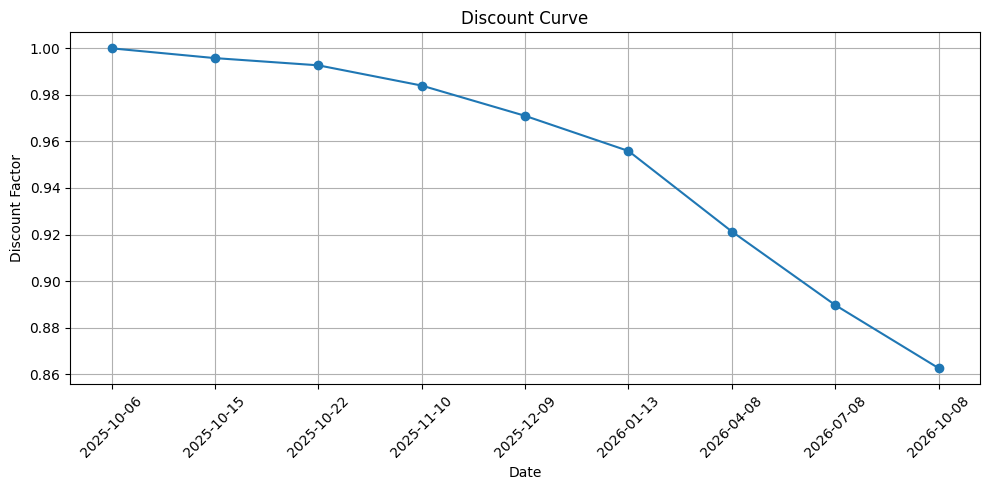

In [4]:
curveDates = [
    "2025-10-06",
    "2025-10-15",
    "2025-10-22",
    "2025-11-10",
    "2025-12-09",
    "2026-01-13",
    "2026-04-08",
    "2026-07-08",
    "2026-10-08"
]

curveDfs = [1.0, 0.9958, 0.9927, 0.9840, 0.9710, 0.9559, 0.9213, 0.8897, 0.8626]

plt.figure(figsize=(10, 5))
plt.plot(curveDates, curveDfs, marker='o')
plt.title("Discount Curve")
plt.xlabel("Date")
plt.ylabel("Discount Factor")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
# ============================
#  ДИСКОНТ-КРИВАЯ
# ============================

curveDates = [
    valueDate,
    ql.Date(15,10,2025),
    ql.Date(22,10,2025),
    ql.Date(10,11,2025),
    ql.Date(9,12,2025),
    ql.Date(13,1,2026),
    ql.Date(8,4,2026),
    ql.Date(8,7,2026),
    ql.Date(8,10,2026)
]

curveDfs = [1.0, 0.9958, 0.9927, 0.9840, 0.9710, 0.9559, 0.9213, 0.8897, 0.8626]



In [6]:
def timeFromToday(date):
    return dayCount.yearFraction(valueDate, date)

times = [timeFromToday(d) for d in curveDates]
logDfs = np.log(curveDfs)

interpLogDf = interp1d(times, logDfs, fill_value="extrapolate")

def discount(t):
    if t < 0:
        return 1.0
    return float(np.exp(interpLogDf(t)))




In [7]:
def Bfunc(t, T):
    return (1 - np.exp(-meanRev * (T - t))) / meanRev

def convexAdj(t0, t1, Tn):
    term = (np.exp(-meanRev*Tn) - np.exp(-meanRev*t1))
    sinhPart = 0.5*(np.exp(meanRev*t0) - np.exp(-meanRev*t0))
    K = (volHW**2 / meanRev**2) * term * sinhPart * Bfunc(t0, t1)
    return np.exp(K)

In [8]:
def makeONschedule(d0, d1):
    """
    Генерация графика overnight (O/N) дат между d0 и d1 с учётом календаря.
    
    Параметры:
        d0: начальная дата (startDate)
        d1: конечная дата (endDate)
    
    Возвращает:
        ds: список рабочих дат O/N
    """
    ds = []
    
    cur = calendar.adjust(d0, conv)  # если d0 попадает на выходной или праздник — переносим
    end = calendar.adjust(d1, conv)  # аналогично для конечной даты
    
    ds.append(cur) 

    while cur < end:
        cur = calendar.advance(cur, ql.Period(1, ql.Days)) 
        cur = calendar.adjust(cur, conv)  
        ds.append(cur)  

    return ds

onDates = makeONschedule(startDate, endDate)
print(f"Количество рабочих O/N дней: {len(onDates)-1}")


Количество рабочих O/N дней: 254


In [9]:
onTimes = [timeFromToday(d) for d in onDates]
Tn = onTimes[-1]


# ============================
#  РАСЧЁТ СТАВОК O/N
# ============================

onRates = []
onTaus = []

for i in range(len(onTimes)-1):
    t0 = onTimes[i]
    t1 = onTimes[i+1]
    tau = t1 - t0

    df0 = discount(t0)
    df1 = discount(t1)

    adj = convexAdj(t0, t1, Tn)

    expectedR = (df0 / df1 * adj - 1.0) / tau

    onRates.append(expectedR)
    onTaus.append(tau)

print("первые 5 O/N ставок:")
for i in range(5):
    print(f"  r[{i}] = {onRates[i]:.6%}")
print()


# ============================
#  СРЕДНЯЯ СТАВКА
# ============================

totalTau = sum(onTaus)
avgON = sum(r*t for r, t in zip(onRates, onTaus)) / totalTau

print(f" Средняя ставка O/N = {avgON:.6%}\n")


# ============================
#  PV FIXED И PV FLOAT
# ============================

tauSwap = onTimes[-1] - onTimes[0]
dfFinal = discount(Tn)

pvFix = notional * fixedRate * tauSwap * dfFinal
pvFloat = notional * avgON * tauSwap * dfFinal

npv = pvFix - pvFloat



print(f"P(0,T) на конец периода: {dfFinal:.6f}")
print(f"PV fixed   = {pvFix:,.2f}")
print(f"PV float   = {pvFloat:,.2f}")
print(f"NPV SWAP   = {npv:,.2f}")


первые 5 O/N ставок:
  r[0] = 17.073196%
  r[1] = 17.061250%
  r[2] = 17.049397%
  r[3] = 17.037637%
  r[4] = 17.034380%

 Средняя ставка O/N = 14.114383%

P(0,T) на конец периода: 0.863180
PV fixed   = 125,161,137.79
PV float   = 121,832,570.28
NPV SWAP   = 3,328,567.51


In [10]:
tauSwap = onTimes[-1] - onTimes[0]  #
dfFinal = discount(Tn)              
print(f"Фиксированная ставка    : {fixedRate:.4%}")


Фиксированная ставка    : 14.5000%
